In [2]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df3 = pd.read_csv('song_recomendation_B.csv')
df3.head(5)

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


In [30]:
df3.shape

(4999, 19)

In [31]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

In [32]:
df3.describe()

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,4999.000000,4747.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4897.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,38.062813,0.607982,0.682576,5.145687,-7.250565,0.694016,0.065305,0.209230,0.027476,0.185169,0.582875,121.731560,3.961177
std,29.501712,0.145108,0.191331,3.566646,3.242031,0.460869,0.062490,0.249858,0.118880,0.147856,0.238784,26.244455,0.262581
min,0.000000,0.000000,0.000020,0.000000,-29.368000,0.000000,0.000000,0.000009,0.000000,0.018500,0.000000,0.000000,0.000000
25%,0.000000,0.516000,0.557000,2.000000,-9.050000,0.000000,0.032900,0.018200,0.000000,0.089200,0.396000,103.005000,4.000000
50%,43.000000,0.616000,0.714000,5.000000,-6.554000,1.000000,0.042700,0.092900,0.000006,0.128000,0.594000,120.853000,4.000000
75%,64.000000,0.708000,0.834000,8.000000,-4.868000,1.000000,0.066800,0.323000,0.000515,0.245000,0.778000,134.797000,4.000000
max,98.000000,0.984000,0.997000,11.000000,-0.276000,1.000000,0.711000,0.987000,0.973000,0.982000,0.991000,213.654000,5.000000


In [73]:
df3.isnull().sum()

Track URI               0
Track Name              0
Artist Name(s)          0
Album Name              0
Album Release Date      2
Popularity              0
Artist Genres         255
Danceability          252
Energy                  2
Key                     2
Loudness                2
Mode                    2
Speechiness             2
Acousticness            2
Instrumentalness      102
Liveness                2
Valence                 2
Tempo                   2
Time Signature          2
dtype: int64

In [75]:
# convert album release date to datetime format
df3['Album Release Date'] = pd.to_datetime(df3['Album Release Date'], errors='coerce')

# fill missing numeric columns using median
numeric_cols = df3.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    median_val = df3[col].median()
    df3[col] = df3[col].fillna(median_val)

# fill missing categorical columns using mode
categorical_cols = df3.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = df3[col].mode()[0]
    df3[col] = df3[col].fillna(mode_val)

In [76]:
# sort by popularity so the most popular version is kept
df3 = (
    df3
    .sort_values('Popularity', ascending=False)
    .drop_duplicates(
        subset=['Track Name', 'Artist Name(s)'],
        keep='first'
    )
)

In [33]:
df3.duplicated().sum()

13

In [ ]:
# remove duplicates in two steps: logical first, then exact full-row

# remove logical duplicates (track name + artist name), keep most popular version
df3 = (
    df3
    .sort_values('Popularity', ascending=False)
    .drop_duplicates(
        subset=['Track Name', 'Artist Name(s)'],
        keep='first'
    )
)

# remove exact full-row duplicates
df3 = df3.drop_duplicates()

# recheck
print("logical duplicates remaining:", 
      df3.duplicated(subset=['Track Name', 'Artist Name(s)']).sum())
print("full-row duplicates remaining:", 
      df3.duplicated().sum())


logical duplicates remaining: 0
full-row duplicates remaining: 0


In [78]:
df3.shape

(4676, 19)

In [79]:
df3.isnull().sum()

Track URI               0
Track Name              0
Artist Name(s)          0
Album Name              0
Album Release Date    680
Popularity              0
Artist Genres           0
Danceability            0
Energy                  0
Key                     0
Loudness                0
Mode                    0
Speechiness             0
Acousticness            0
Instrumentalness        0
Liveness                0
Valence                 0
Tempo                   0
Time Signature          0
dtype: int64

### Plots

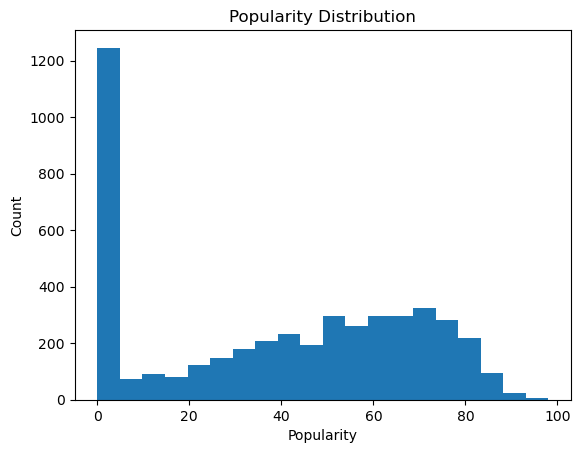

In [82]:
# plot popularity distribution
plt.hist(df3['Popularity'], bins=20)
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

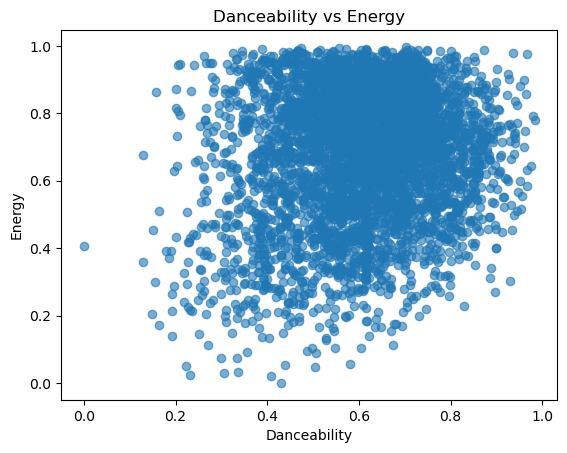

In [84]:
# plot danceability vs energy
plt.scatter(df3['Danceability'], df3['Energy'], alpha=0.6)
plt.title('Danceability vs Energy')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()

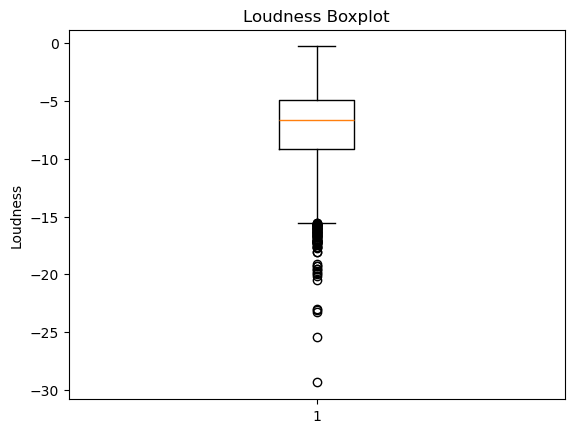

In [ ]:
# plot loudness boxplot
plt.boxplot(df3['Loudness'])
plt.title('Loudness Boxplot')
plt.ylabel('Loudness')
plt.show()

## b. Content-based recommendation system

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# create a content text column
df3['Content Text'] = df3['Track Name'] + ' ' + df3['Artist Name(s)'] + ' ' + df3['Artist Genres']

# fit tfidf vectorizer on content text
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df3['Content Text'])

# scale numeric audio features
audio_features = ['Danceability', 'Energy', 'Valence', 'Tempo']
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df3[audio_features])

# define recommendation function
def recommend_songs(query, top_n=5):
    # vectorize query
    query_vector = tfidf.transform([query])
    
    # compute text similarity
    text_sim = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    similarity = text_sim
    
    # get top_n indices excluding exact matches if exist
    top_indices = similarity.argsort()[::-1][:top_n]
    
    # return track info
    return df3.iloc[top_indices][['Track Name', 'Artist Name(s)', 'Album Name', 'Popularity']]

## c. Input examples (10 inputs)

In [ ]:
recommend_songs("Dance pop Pitbull")


,Track Name,Artist Name(s),Album Name,Popularity
1868,Mmm Yeah (feat. Pitbull),"Austin Mahone, Pitbull",The Secret,0
4112,I'm All Yours,"Jay Sean, Pitbull",I'm All Yours,49
1901,On The Floor - Radio Edit,"Jennifer Lopez, Pitbull",On The Floor,0
268,Hotel Room Service,Pitbull,Hotel Room Service,66
2041,"Back in Time - featured in ""Men In Black 3""",Pitbull,Global Warming (Deluxe Version),28


In [ ]:
recommend_songs("classic rock Fleetwood Mac")

,Track Name,Artist Name(s),Album Name,Popularity
2848,Go Your Own Way,Fleetwood Mac,Rumours,0
4588,Albatross,Fleetwood Mac,Fleetwood Mac's Greatest Hits,34
593,The Chain - 2004 Remaster,Fleetwood Mac,Rumours (Super Deluxe),86
3,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,79
3449,It's Hard to Be Humble,Mac Davis,Stop And Smell The Roses,50


In [ ]:
recommend_songs("Britney Spears pop ballad")

,Track Name,Artist Name(s),Album Name,Popularity
1012,3,Britney Spears,The Singles Collection,64
569,Sometimes,Britney Spears,...Baby One More Time (Digital Deluxe Version),72
556,I Love Rock 'N' Roll,Britney Spears,Britney (Digital Deluxe Version),60
4443,Lucky,Britney Spears,Oops!... I Did It Again,71
3912,...Baby One More Time,Britney Spears,...Baby One More Time (Digital Deluxe Version),83


In [99]:
recommend_songs("pop r&b Khalid")

,Track Name,Artist Name(s),Album Name,Popularity
1374,Up All Night,Khalid,Up All Night,65
4241,Better,Khalid,Suncity,81
1199,lovely (with Khalid),"Billie Eilish, Khalid",lovely (with Khalid),91
2542,Saved,Khalid,American Teen,69
4,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),78


In [100]:
recommend_songs("electropop Halsey")

,Track Name,Artist Name(s),Album Name,Popularity
3245,Now Or Never,Halsey,hopeless fountain kingdom (Deluxe),68
3446,Closer,"The Chainsmokers, Halsey",Closer,87
2546,Graveyard,Halsey,Manic,70
4,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),78
3165,The Feeling,"Justin Bieber, Halsey",Purpose (Deluxe),0


In [101]:
recommend_songs("album rock Rolling Stones")

,Track Name,Artist Name(s),Album Name,Popularity
2,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,0
3579,It's All Over Now - Mono Version,The Rolling Stones,12 X 5,48
2909,We Love You - Single Version/Mono,The Rolling Stones,The Rolling Stones In Mono (Remastered 2016),40
2329,As Tears Go By - Mono Version,The Rolling Stones,December’s Children (And Everybody’s),60
2958,Start Me Up - Remastered 2009,The Rolling Stones,Tattoo You (2009 Re-Mastered),82


In [102]:
recommend_songs("yang rock rock gitu")

,Track Name,Artist Name(s),Album Name,Popularity
1181,Go Now!,The Moody Blues,An Introduction to the Moody Blues,0
1015,Life's Been Good,Joe Walsh,"But Seriously, Folks...",71
3161,R.O.C.K. In The U.S.A. (A Salute To 60's Rock),John Mellencamp,Scarecrow (Remastered),0
4044,Rock'n Me,Steve Miller Band,Fly Like An Eagle,74
1727,Do It Again,Steely Dan,Can't Buy A Thrill,6


In [103]:
recommend_songs("chill")

,Track Name,Artist Name(s),Album Name,Popularity
2494,"Flashlight - From ""Pitch Perfect 2"" Soundtrack",Jessie J,"Flashlight (From ""Pitch Perfect 2"" Soundtrack)",0
2450,Times Like These,Foo Fighters,Greatest Hits,58
4218,Nutbush City Limits,Ike & Tina Turner,Tina!,58
1434,Step by Step,Whitney Houston,The Preacher's Wife,58
1074,Resolution,Matt Corby,Resolution - EP,58


In [109]:
recommend_songs("movie soundtrack")

,Track Name,Artist Name(s),Album Name,Popularity
406,Too Young,Donny Osmond,Too Young,36
1379,One Call Away,"Chingy, Jason Weaver",Jackpot,65
1764,Rewrite The Stars,"Zac Efron, Zendaya",Rewrite The Stars,76
2540,This Is Me,"Keala Settle, The Greatest Showman Ensemble",This Is Me,68
2494,"Flashlight - From ""Pitch Perfect 2"" Soundtrack",Jessie J,"Flashlight (From ""Pitch Perfect 2"" Soundtrack)",0


In [113]:
recommend_songs("songs by benny")

,Track Name,Artist Name(s),Album Name,Popularity
3014,Into The Night,Benny Mardones,Never Run Never Hide,61
3119,Sad Songs (Say So Much),Elton John,To Be Continued...,0
3351,I Write The Songs,Barry Manilow,The Greatest Songs Of The Seventies,45
1117,Cinema (feat. Gary Go),Benny Benassi,Electroman,0
2277,Ernie (The Fastest Milkman in the West),Benny Hill,Ernie (The Fastest Milkman In The West) [With ...,38
